In [10]:
# グラフの実行と結果の表示
def stream_graph_updates(user_input: str):
    events = graph.stream(
        {"messages": [("user", user_input)]},
        {"configurable": {"thread_id": "1"}},
        stream_mode="values")
    # 結果をストリーミングで得る
    for event in events:
        print(event["messages"][-1].content, flush=True)

# チャットボットのループ
while True:
    user_input = input("質問:")
    if user_input.strip()=="":
        print("ありがとうございました!")
        break
    stream_graph_updates(user_input)

こんにちは！
こんにちは！今日はどんなことをお手伝いできますか？
1足す2は？
1足す2は3です。
1メートル以上の魚は？

[{"title": "【怪魚釣り】メーターオーバーの怪魚たちを難易度別にご紹介 | 【TSURI HACK】日本最大級の釣りマガジン - 釣りハック", "url": "https://tsurihack.com/8448", "content": "他人に認められる魚とか、SNSでイイネをたくさんもらえそうな魚とかでも良いかもしれませんが、大切なのは、“自分が釣ってみたい魚や大きさ”を意識すること。\n\n僕はいつも、自分の好奇心と探求心を一番大切にするように心がけています。\n\n### 何処でどんな釣り具を使えば釣れるか勉強しましょう\n\n大物釣りの調査\n\n大物釣りの調査\n\n目標とする魚が決まったら、その魚の生態や生息域を勉強しましょう。\n\nこのステップをすっ飛ばしてしまうと、“釣れた魚や釣り場の環境に対する想いや価値観”が半減してしまいがちに……。\n\nたとえ誰かに釣り場を案内してもらう時であっても、釣りたい魚がどんな環境で暮らしている生き物なのか図鑑や文献などで簡単にでも調べておくと良いですよ。\n\n### 諦めずに釣り場に通いましょう\n\n釣り\n\n釣り\n\n魚種やサイズによって大物釣りの難易度は、1日で釣れるものから数年かかるものまで様々です。\n\n自分が定めた目標に向かって、釣れない日や掛かってもバラしてしまう日だってあるかもしれませんが、諦めずに釣り場に通ってみましょう。\n\n手早く、狙った大物を釣り上げる腕利きの釣り人の方がカッコ良く見えるかもしれませんが、僕はたくさん努力したことで全身が震えるあの感動を味わえている人も素敵だなといつも感じます。\n\n## 近所に潜む大物10選＆レア度をご紹介\n\n### 大物は意外と身近にもいるんです\n\nそれでは、ここからは身近な水辺に生息する大物達を釣り上げる難易度別にご紹介していきます。\n\nどの魚も、陸っぱりで狙えて最大全長が1mを超えるものばかり！\n\nお住まいの地域にこれからリストアップする魚が生息していたら、狙ってみてはいかがでしょうか。\n\n## 鯉｜もっとも手軽で簡単な大物 [...] ## 鯉｜もっとも手軽で簡単な大物\n\n

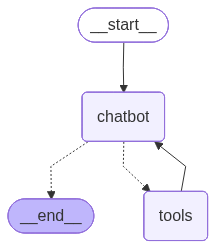

In [9]:
# グラフの可視化
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

# ツールノードの作成
tool_node = ToolNode(tools)

# グラフにツールノードを追加
graph_builder.add_node("tools", tool_node)

# 条件付エッジの作成
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition, # ツール呼出と判断したらツールノードを呼ぶ
)

# ツールが呼び出されるたびに、チャットボットに戻って次のステップを決定
# ツールからチャットボットへの戻りエッジを作成
graph_builder.add_edge("tools", "chatbot")

# 開始ノードの指定
graph_builder.set_entry_point("chatbot")

# 記憶を持つ実行可能なステートグラフの作成
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

In [7]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages

# Stateクラスの定義
class State(TypedDict):
    messages: Annotated[list, add_messages]

# グラフのインスタンスを作成
graph_builder = StateGraph(State)

# 言語モデルの定義
llm = ChatOpenAI(model_name=MODEL_NAME)

# 変更点：ツール定義の紐づけ
llm_with_tools = llm.bind_tools(tools)

# チャットボットノードの作成
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# グラフにチャットボットノードを追加
graph_builder.add_node("chatbot", chatbot)

In [3]:
tool.invoke("Langgraphのノードとは？")

[{'title': 'What is LangGraph? - IBM',
  'url': 'https://www.ibm.com/think/topics/langgraph',
  'content': 'Nodes: In LangGraph, nodes represent individual components or agents within an AI workflow. Nodes can be thought of as “actors” that interact with each other in a specific way. For example,to add nodes for tool calling, one can use the ToolNode. Another example, the next node, refers to the node that will be executed following the current one.\n\nEdges: Edges are a function within Python that determines which node to execute next based on the current state. Edges can be conditional branches or fixed transitions.\n\n#### Tools\n\nRAG: Retrieval-augmented generation (RAG) combines the power of LLMs with contextual information from external sources by retrieving relevant documents, which are then used as input for answer generation. [...] Workflows: Workflows are the sequences of node interactions that define an AI workflow. By arranging nodes into a workflow, users can create more 

In [2]:
# 検索ツールの定義
from langchain_community.tools.tavily_search import TavilySearchResults

tool = TavilySearchResults(max_results=2)
tools = [tool]

In [6]:
# 必要なモジュールをインポート
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

# 環境変数の読み込み
load_dotenv("../.env")
os.environ['OPENAI_API_KEY'] = os.environ['API_KEY']

# モデル名
MODEL_NAME = "gpt-4o-mini"